# Optimizacija dimenzioniranja sončne elektrarne glede na tržne cene in profil odjema

## 1. Opis problema in cilj naloge
Cilj projektne naloge je določiti **optimalno nazivno moč sončne elektrarne (SE)** za konkreten odjem električne energije.

Pri analizi upoštevamo:
- urni profil porabe električne energije (telemetrija),
- urne borzne SPOT cene električne energije v Sloveniji za leto 2024,
- simulirano urno proizvodnjo sončne elektrarne (PVGIS),
- vse tarifne postavke (omrežnina VT/MT, prispevki OIE+SPTE, trošarina) ter investicijske stroške (CAPEX) glede na velikost naprave,
- omejitev odjema

Cilj je najti takšno velikost SE, ki minimizira celotne letne stroške oziroma minimizira **ekonomsko dobo vračanja (EDV)**.

## 2. Pridobivanje podatkov s spleta
Podatke zajemamo neposredno prek dveh javnih spletnih vmesnikov (API):
1. **Energy-Charts API**: Borzne SPOT cene električne energije za območje Slovenije (`SI`).
2. **PVGIS API (Evropska komisija)**: Simulacija urnega sončnega obsevanja in proizvodnje za 1 kW sončne elektrarne na lokaciji, kjer jo želimo postaviti.

In [114]:
import os
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [115]:
#Določim pot do mape "podatki", ki sem jo ustvarila prej, sem se bojo shranjevali podatki iz spleta.

def prenesi_spot_cene(leto=2024, drzava="SI"): 
    #prenese urne SPOT cene za Slovenijo v letu 2025
    os.makedirs(MAPA_PODATKI, exist_ok=True)
    pot_datoteke = os.path.join(MAPA_PODATKI, f"spot_cene.csv")

    start = f"{leto}-01-01"
    end = f"{leto}-12-31"
    url = f"https://api.energy-charts.info/price?bzn={drzava}&start={start}&end={end}"
    print(f"Prenašam SPOT cene za državo {drzava} za leto {leto}...")
    #Sporoči morebitno napako
    odziv = requests.get(url, timeout=30)
    if odziv.status_code != 200:
        raise ConnectionError(f"Napaka pri prenosu SPOT cen: koda {odziv.status_code}")

    podatki = odziv.json()
    casovni_zigi = pd.to_datetime(podatki["unix_seconds"], unit = "s")
    cene = podatki ["price"]

    df_spot = pd.DataFrame({
        "Timestamp": casovni_zigi,
        "SPOT_EUR_MWh": cene
    })

    #Shranim v CSV
    df_spot.to_csv(pot_datoteke, index=False)
    print(f" -> SPOT cene uspešno shranjene v: {pot_datoteke} (št. vrstic: {len(df_spot)})")
    return df_spot

def prenesi_proizvodnjo(lat = 46.0569, lon = 14.5058, leto = 2020, moc_kw = 1.0):
    #privzete koordinate so LJ, jemljem iz API-ja PVGIS(Evropska komisija), vzamem normiran podatek
    os.makedirs(MAPA_PODATKI, exist_ok = True)
    pot_datoteke = os.path.join(MAPA_PODATKI, f"pvgis_proizvodnja.csv")
    url = "https://re.jrc.ec.europa.eu/api/v5_2/seriescalc"
    parametri = {
        "lat": lat,
        "lon": lon,
        "peakpower": moc_kw,
        "pvcalculation": 1,
        "optimalangles": 1,
        "outputformat": "json",
        "startyear": leto,      
        "endyear": leto,
        "loss": 14       
    }
    print(f"[2/2] Prenašam podatke o sončnem obsevanju s PVGIS za lokacijo ({lat}, {lon})...")
    odziv = requests.get(url, params=parametri, timeout=30)
    if odziv.status_code != 200:
        raise ConnectionError(f"Napaka pri prenosu PVGIS podatkov: koda {odziv.status_code}")

    podatki = odziv.json()
    urna_serija = podatki["outputs"]["hourly"]

    casi = []
    moci_w = []
    for vnos in urna_serija:
        # Oblika časa v PVGIS: "20200101:0010"
        casi.append(pd.to_datetime(vnos["time"], format="%Y%m%d:%H%M"))
        moci_w.append(vnos["P"])  # Moč v W

    df_pvgis = pd.DataFrame({
        "Timestamp": casi,
        "Proizvodnja_normirano": [p / 1000.0 for p in moci_w]  # Pretvornik v kWh za 1 kW SE
    })

    df_pvgis.to_csv(pot_datoteke, index=False)
    print(f" -> PVGIS podatki uspešno shranjeni v: {pot_datoteke} (št. vrstic: {len(df_pvgis)})")
    return df_pvgis

#Vnos željene lokacije
vnos_lat = input(f"Vnesite zemljepisno širino, kjer bo postavljena SE (ali pritisnite Enter za Ljubljana): ").strip()
if vnos_lat == "":
     lat = 46.0569
else:
    try:
        lat = float(vnos_lat.replace(',','.'))
    except ValueError:
        print("Vaš vnos ni veljaven. Uporabljam privzeto vrednost (Ljubljana).")
vnos_lon = input(f"Vnesite zemljepisno dolžino, kjer bo postavljena SE (ali pritisnite Enter za Ljubljana): ").strip()
if vnos_lon == "":
     lon = 14.5058
else:
    try:
        lon = float(vnos_lon.replace(',','.'))
    except ValueError:
        print("Vaš vnos ni veljaven. Uporabljam privzeto vrednost (Ljubljana).")
print(f"Izbrana lokacija za SE: širina = {lat:.4f}, dolžina = {lon:.4f}")

if __name__ == "__main__":
    print("=== ZAGON PRENOSA PODATKOV S SPLETA ===")
    prenesi_spot_cene(leto=2024, drzava="SI")
    prenesi_proizvodnjo(lat=46.0569, lon=14.5058, leto=2020)
    print("=== PRENOS USPEŠNO ZAKLJUČEN ===")

Izbrana lokacija za SE: širina = 46.0569, dolžina = 14.5058
=== ZAGON PRENOSA PODATKOV S SPLETA ===
Prenašam SPOT cene za državo SI za leto 2024...
 -> SPOT cene uspešno shranjene v: c:\Users\Nika\Documents\Projektna_naloga_UVP\projektna-naloga-programiranje\podatki\spot_cene.csv (št. vrstic: 8784)
[2/2] Prenašam podatke o sončnem obsevanju s PVGIS za lokacijo (46.0569, 14.5058)...
 -> PVGIS podatki uspešno shranjeni v: c:\Users\Nika\Documents\Projektna_naloga_UVP\projektna-naloga-programiranje\podatki\pvgis_proizvodnja.csv (št. vrstic: 8784)
=== PRENOS USPEŠNO ZAKLJUČEN ===


## 1. Funkcije za izračune in obdelavo podatkov
Spodaj so definirane funkcije za čiščenje cen, oblikovanje zneskov ter matematični modeli za izračun bilanc in stroškov.

In [ ]:
# ==========================================
# 1. FUNKCIJE 
# ==========================================
limit_moci_kw = 300 #Ko boš konec z ostalim naredi da to uporabnik sam vnese
#-----Pomožni funkciji
def ocisti_ceno(tekst):
    if isinstance(tekst, str):
        stevilka_del = tekst.split(' ')[0]
        return float(stevilka_del.replace(',', '.'))
    return tekst
# 2. Oblikovanje številk (€ in vejice)- za lepši Excel
def formatiraj_eur(x):
    return f"{x:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.')

#-------Funkcije, ki jih uporabljam v izračunu
def izracunaj_f(i, p, s_base):
    S_i = s_base * i
    direktna_poraba = np.minimum(S_i, p)
    viski = np.maximum(S_i - p, 0)
    manjki = np.maximum(p - S_i, 0)
    return np.sum(direktna_poraba) - np.sum(viski) - np.sum(manjki)

def izracunaj_f_ura(i, p, s_base):
    S_i = s_base * i
    direktna_poraba = np.minimum(S_i, p)
    viski = np.maximum(0, S_i - p)
    manjki = np.maximum(0, p - S_i)
    return np.sum(direktna_poraba) - np.sum(viski) - np.sum(manjki)

def celotna_bilanca(row, p, s_base, stroski_df, spot_podatki, df_leto_ref, marza1=5):
    df_omreznina1 = df_leto_ref['Tarifa (VT/MT)']
    df_omreznina2 = stroski_df.loc['PowerNetworkFee', 'Cena_num']
    df_meritve    = stroski_df.loc['DutyMeteringPoint', 'Cena_num']
    df_OIEK       = stroski_df.loc['DutyOIEK', 'Cena_num']
    df_PiOI       = stroski_df.loc['DutyPiOI', 'Cena_num']
    df_trosarina  = stroski_df.loc['ExciseTax', 'Cena_num']
    spot_kwh = spot_podatki / 1000 
    marza1_kwh = marza1 / 1000
    
    # Razporeditev omrežnine
    omreznina_kwh = np.where(df_omreznina1 == "MT", 0.01695, 0.03724)
    
    moc_kw = row['Moc_SE_kW']
    capex_skupaj = row['CAPEX_EUR']
    letni_strosek_capex = capex_skupaj / 30
    i_energija = moc_kw * 1050
    S_i = s_base * i_energija
    viski = np.maximum(S_i - p, 0)
    manjki = np.maximum(p - S_i, 0)
    limit = limit_moci_kw
    manjki_dejanski = manjki
    viski_dejanski = np.minimum(viski, limit)

    
    variabilni_strosek_kwh = spot_kwh + marza1_kwh + omreznina_kwh + df_OIEK + df_PiOI + df_trosarina
    strosek_nakupa = np.sum(manjki_dejanski * variabilni_strosek_kwh)  
    strosek_fiksni = (df_omreznina2 * limit_moci_kw) + (df_meritve * 12)
    zasluzek_viski = np.sum((spot_kwh - marza1_kwh) * viski_dejanski)
    skupni_letni_strosek = (strosek_fiksni + letni_strosek_capex + strosek_nakupa - zasluzek_viski) * 1.13

    return {
        'Skupaj' : skupni_letni_strosek,
        'Energija': np.sum(manjki * spot_kwh) * 1.13,
        'Omreznina': (np.sum(manjki * omreznina_kwh) + df_omreznina2 * limit_moci_kw) * 1.13,
        'Prispevki': (df_meritve * 12 + np.sum((df_OIEK + df_PiOI) * manjki)) * 1.13,
        'Trosarina': np.sum(df_trosarina * manjki) * 1.13,
        'CAPEX': letni_strosek_capex * 1.13,
        'Viski': zasluzek_viski * 1.13
    }

## 2. Vnos parametrov in uvoz podatkov
Nalaganje podatkov o SPOT cenah, PVGIS sončni proizvodnji ter Excel datoteke s telemetrijo in tarifami.

In [117]:
# ==========================================
# 2. PODATKI 
# ==========================================
#Uporabnik ima možnost, da podatke vnese sam ali uporabi moj model.
#Vnos omejitve moči:
vnos_moc = input("Vnesite priključno moč / omejitev odjema v kW [privzeta vrednost: 300]: ").strip()
if vnos_moc == "":
    limit_moci_kw = 300.0
else:
    try:
        limit_moci_kw = float(vnos_moc.replace(',','.'))
    except ValueError:
        print("Vaš vnos ni veljaven. Uporabljam privzeto vrednost 300 kW.")
print(f"Izbrana omejitev moči: {limit_moci_kw:.1f} kW")

#Vnos lastne telemetrije:
privzeta_datoteka = "Podatki_Optimizacija1.xlsx"
vnos_datoteka = input(f"Vnesite ime Excel datoteke z meritvami (ali pritisnite Enter za '{privzeta_datoteka}'): ").strip()

if vnos_datoteka == "":
    pot_excel = os.path.join(os.getcwd(), privzeta_datoteka)
else:
    pot_excel = os.path.join(os.getcwd(), vnos_datoteka)

if not os.path.exists(pot_excel):
        print(f"OPOZORILO: Datoteka '{pot_excel}' ne obstaja! Uporabljena bo privzeta datoteka '{privzeta_datoteka}'.")
        pot_excel = os.path.join(os.path.dirname(__file__), privzeta_datoteka)  
print(f"Berem podatke iz: {os.path.basename(pot_excel)}")
     
MAPA_PODATKI = os.path.join(os.getcwd(), "podatki")
df_spot = pd.read_csv(os.path.join(MAPA_PODATKI, "spot_cene.csv"))
df_pvgis = pd.read_csv(os.path.join(MAPA_PODATKI, "pvgis_proizvodnja.csv"))

#Podatki iz mojih excelov(15-min meritve odjema, capex in tarife):
ostali_podatki = os.path.join(os.getcwd(), "Podatki_Optimizacija1.xlsx")
vsi_listi = pd.read_excel(ostali_podatki, sheet_name=None)
df_odjem_15min = vsi_listi["Telemetrija"]
df_capex = vsi_listi["Cenik_SE"]
df_stroski = vsi_listi["Tarife"].copy().set_index('Postavka')
df_stroski['Cena_num'] = df_stroski['Cena'].apply(ocisti_ceno)

#15-min podatke pretvorim v urne
df_odjem_15min['Timestamp'] = pd.to_datetime(df_odjem_15min['Timestamp'])
df_odjem_15min = df_odjem_15min.set_index('Timestamp')
df_odjem = df_odjem_15min.resample('1h').agg({
    'reg_A_plus': 'sum',
    'Tarifa (VT/NT)': 'first'
}).reset_index()


df_spot['Timestamp'] = pd.to_datetime(df_spot['Timestamp'])
df_pvgis['Timestamp'] = pd.to_datetime(df_pvgis['Timestamp'])
#varovalka, če bi izbrali kombinacijo let, ki nimajo isto dni
st_ur = min(len(df_spot), len(df_pvgis), len(df_odjem))

#združitev
df_leto = pd.DataFrame({
    'Timestamp': df_spot['Timestamp'].iloc[:st_ur].values,
    'SPOT_EUR_MWh': df_spot['SPOT_EUR_MWh'].iloc[:st_ur].values,
    'Proizvodnja_normirano': df_pvgis['Proizvodnja_normirano'].iloc[:st_ur].values / df_pvgis['Proizvodnja_normirano'].iloc[:st_ur].values.sum(),
    'Odjem_kWh': df_odjem['reg_A_plus'].iloc[:st_ur].values,
    'Tarifa (VT/MT)': df_odjem['Tarifa (VT/NT)'].iloc[:st_ur].values
})
#Vektorji za nadaljne računanje
poraba = df_leto['Odjem_kWh'].values
bazicna_proizvodnja = df_leto['Proizvodnja_normirano'].values
SPOT_cena = df_leto['SPOT_EUR_MWh'].values
tarifa = df_leto['Tarifa (VT/MT)'].values

Izbrana omejitev moči: 300.0 kW
Berem podatke iz: Podatki_Optimizacija1.xlsx


## 3. Optimizacija samooskrbe na letni in dnevni ravni
Iskanje optimalne velikosti glede na največjo samooskrbnost skozi celotno leto ter za povprečen dan.

OPTIMIZACIJA SONČNA ELEKTRARNA
------------------------------------------------------------
CILJ: največja samooskrbnost
Optimalna letna količna proizvedene energije: 548548.59 kWh
Optimalna velikost: 522.43 kW


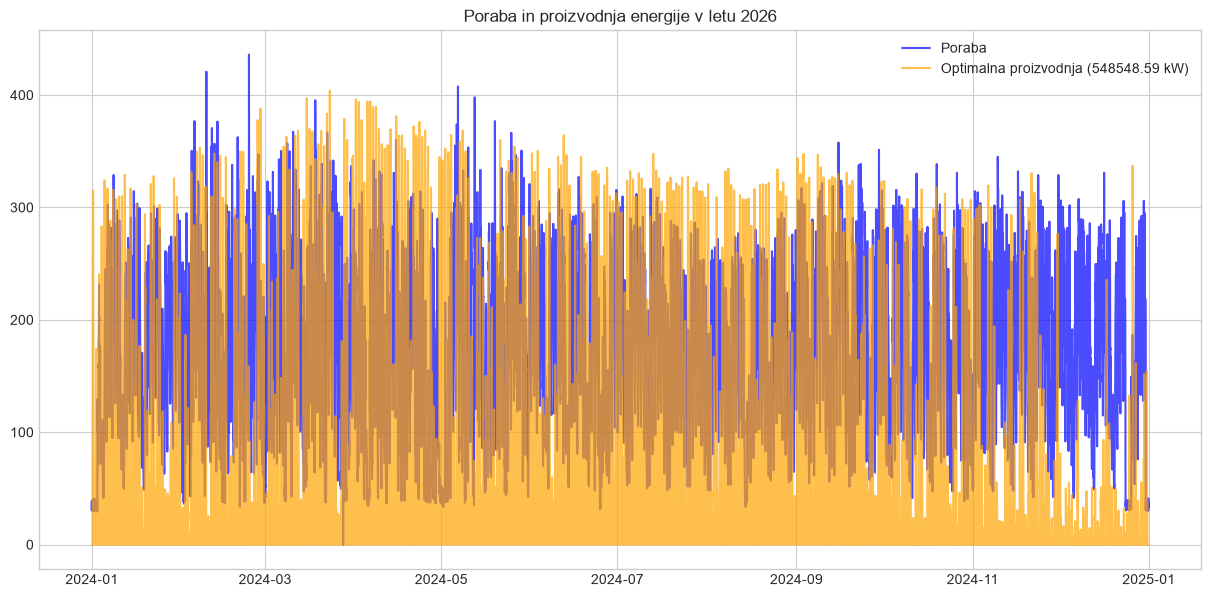

Optimalna dnevna količna proizvedene energije: 692692.72 kWh
Optimalna velikost: 659.71 kW


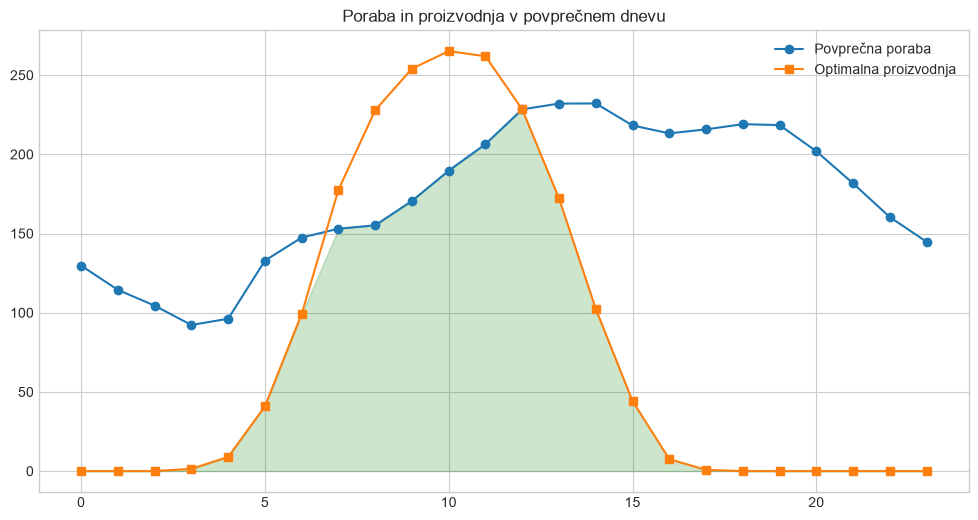

In [118]:
# ==========================================
# 3. IZVEDBA (Izračuni in grafi)
# ==========================================

print("OPTIMIZACIJA SONČNA ELEKTRARNA")
print("-" * 60)

# 1. Letna raven
print("CILJ: največja samooskrbnost")
velikosti = np.linspace(0.1, 1000000, 1000)
rezultati = [izracunaj_f(i, poraba, bazicna_proizvodnja) for i in velikosti]
optimalni_i = velikosti[np.argmax(rezultati)]
print(f"Optimalna letna količna proizvedene energije: {optimalni_i:.2f} kWh")
proizvodnja_optimalna = bazicna_proizvodnja * optimalni_i
print(f"Optimalna velikost: {optimalni_i / 1050:.2f} kW")

# Graf 1
plt.figure(figsize=(15, 7))
plt.plot(df_leto['Timestamp'], df_leto['Odjem_kWh'], label='Poraba', color='blue', alpha=0.7)
plt.plot(df_leto['Timestamp'], proizvodnja_optimalna, label=f'Optimalna proizvodnja ({optimalni_i:.2f} kW)', color='orange', alpha=0.7)
plt.title('Poraba in proizvodnja energije v letu 2026')
plt.legend()
plt.grid(True)
plt.show()

# 2. Povprečne ure
df_ura = df_leto.groupby(df_leto['Timestamp'].dt.hour).mean(numeric_only=True)
povprecna_poraba = df_ura['Odjem_kWh'].values
povprečna_proizvodnja = df_ura['Proizvodnja_normirano'].values

rezultati_ura = [izracunaj_f_ura(i, povprecna_poraba, povprečna_proizvodnja) for i in velikosti]
optimalni_i_ura = velikosti[np.argmax(rezultati_ura)]
print(f"Optimalna dnevna količna proizvedene energije: {optimalni_i_ura:.2f} kWh")
print(f"Optimalna velikost: {optimalni_i_ura / 1050:.2f} kW")

# Graf 2
plt.figure(figsize=(12, 6))
ure = range(24)
proizvodnja_optimalna_ura = povprečna_proizvodnja * optimalni_i_ura
plt.plot(ure, povprecna_poraba, label='Povprečna poraba', marker='o')
plt.plot(ure, proizvodnja_optimalna_ura, label='Optimalna proizvodnja', marker='s')
plt.fill_between(ure, np.minimum(povprecna_poraba, proizvodnja_optimalna_ura), color='green', alpha=0.2)
plt.title('Poraba in proizvodnja v povprečnem dnevu')
plt.legend()
plt.grid(True)
plt.show()

## 4. Ekonomska optimizacija (SPOT cene, CAPEX in celotna bilanca)
Izračun stroškovnih bilanc glede na tržne SPOT cene, investicijske stroške (CAPEX) in dajatve ter iskanje optimalne velikosti glede na ekonomsko dobo vračanja (EDV).


------------------------------------------------------------
CILJ: NAJNIŽJI CELOTNI LETNI STROŠEK
Optimalna velikost: 900 kW
Letni strošek s SE: 182408.07 €
Letni strošek brez SE: 259248.90 €
Prihranek s SE: 76840.83 €
------------------------------------------------------------
 REZULTATI ZA VSE VELIKOSTI SE 
Velikost SE:   100.0 kW | EDV: 5.435 let | Letni prihranek: 11782.60 €
Velikost SE:   150.0 kW | EDV: 5.105 let | Letni prihranek: 17706.39 €
Velikost SE:   200.0 kW | EDV: 4.876 let | Letni prihranek: 23559.75 €
Velikost SE:   250.0 kW | EDV: 4.841 let | Letni prihranek: 29178.50 €
Velikost SE:   300.0 kW | EDV: 4.867 let | Letni prihranek: 34533.22 €
Velikost SE:   350.0 kW | EDV: 4.918 let | Letni prihranek: 39539.29 €
Velikost SE:   400.0 kW | EDV: 4.994 let | Letni prihranek: 44124.73 €
Velikost SE:   500.0 kW | EDV: 5.227 let | Letni prihranek: 52244.38 €
Velikost SE:   600.0 kW | EDV: 5.287 let | Letni prihranek: 59844.32 €
Velikost SE:   700.0 kW | EDV: 5.507 let | Letni 

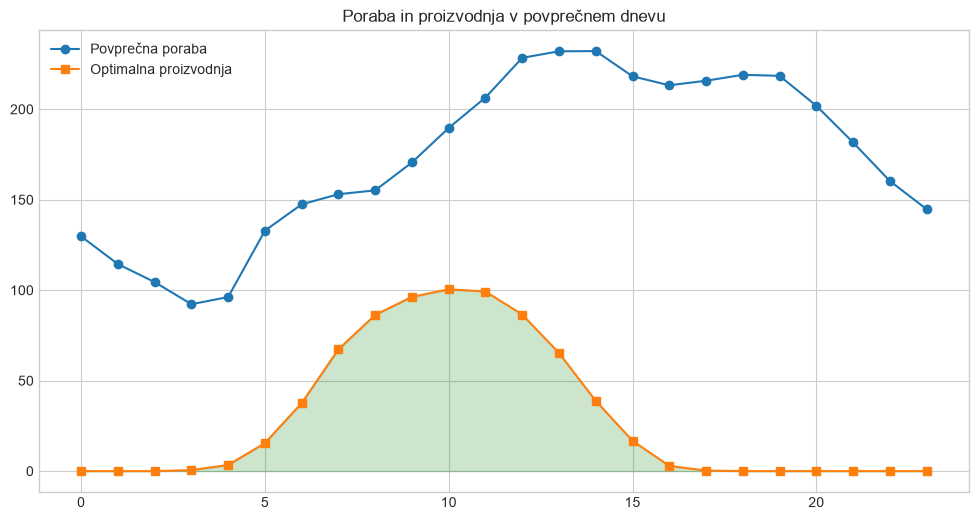

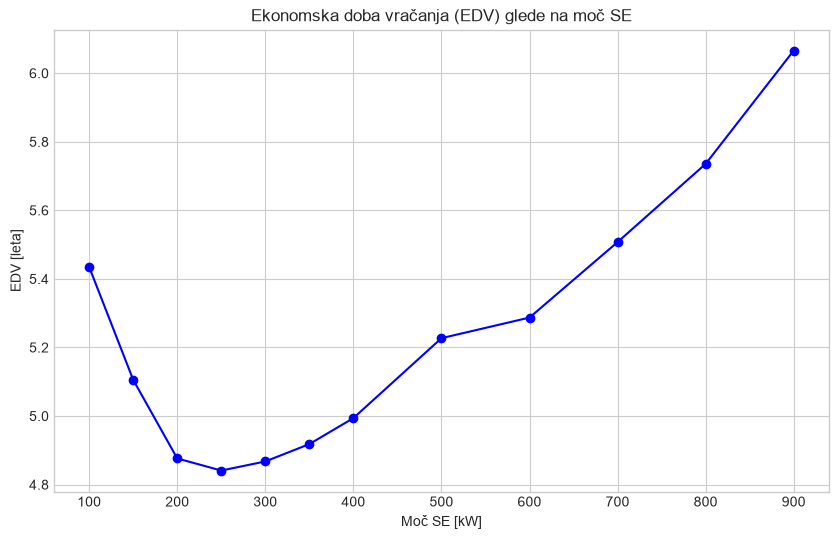


[USPEH] Rezultati so shranjeni v datoteko: Rezultati_Optimizacije_250kW.xlsx


In [119]:
scenariji = df_capex.copy()
# 5. Celotna bilanca
print("-" * 60)
print("CILJ: NAJNIŽJI CELOTNI LETNI STROŠEK")
scenariji['Rezultat_dict'] = scenariji.apply(lambda row: celotna_bilanca(row, poraba, bazicna_proizvodnja, df_stroski, SPOT_cena, df_leto), axis=1)
scenariji['Strosek_EUR'] = scenariji['Rezultat_dict'].apply(lambda x: x['Skupaj'])

# Izračun stanja BREZ SE
omr_kwh_brez = np.where(df_leto['Tarifa (VT/MT)'] == "MT", 0.01695, 0.03724)
strosek_fiksni_brez = (df_stroski.loc['PowerNetworkFee','Cena_num'] * limit_moci_kw) + (df_stroski.loc['DutyMeteringPoint','Cena_num'] * 12)
var_strosek_brez = SPOT_cena/1000 + 5/1000 + omr_kwh_brez + df_stroski.loc['DutyOIEK','Cena_num'] + df_stroski.loc['DutyPiOI','Cena_num'] + df_stroski.loc['ExciseTax','Cena_num']
strosek_brez_SE_full = (np.sum(poraba * var_strosek_brez) + strosek_fiksni_brez) * 1.13

najboljsa_opcija_final = scenariji.loc[scenariji['Strosek_EUR'].idxmin()]
print(f"Optimalna velikost: {najboljsa_opcija_final['Moc_SE_kW']} kW")
print(f"Letni strošek s SE: {najboljsa_opcija_final['Strosek_EUR']:.2f} €")
print(f"Letni strošek brez SE: {strosek_brez_SE_full:.2f} €")
print(f"Prihranek s SE: {strosek_brez_SE_full - najboljsa_opcija_final['Strosek_EUR']:.2f} €")

# Rezultati za vse velikosti
print("-" * 60)
print(" REZULTATI ZA VSE VELIKOSTI SE ")
edv_seznam, donosnost_seznam = [], []
for idx, row in scenariji.iterrows():
    prihranek_v = strosek_brez_SE_full - row['Strosek_EUR']
    edv_v = row['CAPEX_EUR'] / prihranek_v if prihranek_v > 0 else 0
    edv_seznam.append(edv_v)
    donosnost_seznam.append((prihranek_v * 30) / row['CAPEX_EUR'])
    print(f"Velikost SE: {row['Moc_SE_kW']:7.1f} kW | EDV: {edv_v:5.3f} let | Letni prihranek: {prihranek_v:5.2f} €")


scenariji['EDV_let'] = edv_seznam
najboljsa_edv = scenariji.loc[scenariji['EDV_let'][scenariji['EDV_let']>0].idxmin()]
opt_res_edv = najboljsa_edv['Rezultat_dict']

# Tabela primerjave
strosek_brez_spot = np.sum(poraba * (SPOT_cena/1000 + 5/1000)) * 1.13
strosek_brez_omr = (np.sum(poraba * omr_kwh_brez) + df_stroski.loc['PowerNetworkFee','Cena_num']* limit_moci_kw) * 1.13
strosek_brez_pris = (df_stroski.loc['DutyMeteringPoint','Cena_num']*12 + np.sum((df_stroski.loc['DutyOIEK','Cena_num']+df_stroski.loc['DutyPiOI','Cena_num'])*poraba)) * 1.13
strosek_brez_tros = np.sum(df_stroski.loc['ExciseTax','Cena_num'] * poraba) * 1.13
print("-" * 60)
print("OPTIMALNA VELIKOST GLEDE NA EDV:")
print(f"Optimalna velikost: {najboljsa_edv['Moc_SE_kW']} kW")
print(f"Letni strošek s SE: {najboljsa_edv['Strosek_EUR']:.2f} €")
print(f"Letni strošek brez SE: {strosek_brez_SE_full:.2f} €")
prihranek_edv = strosek_brez_SE_full - najboljsa_edv['Strosek_EUR']
print(f"Prihranek s SE: {prihranek_edv:.2f} €")
print(f"EDV: {najboljsa_edv['EDV_let']:.2f} let")
opt_res_edv = najboljsa_edv['Rezultat_dict']
primerjava = {
    'Kategorija': ['Znesek energije', 'Znesek omrežnine', 'Znesek ostalih prispevkov', 'Znesek trošarine', 'Zaslužek od viškov', 'Znesek capex', 'SKUPAJ'],
    'Strošek pred': [round(strosek_brez_spot, 2), round(strosek_brez_omr, 2), round(strosek_brez_pris, 2), round(strosek_brez_tros, 2), 0, 0, round(strosek_brez_SE_full, 2)],
    'Strošek po': [opt_res_edv['Energija'], opt_res_edv['Omreznina'], opt_res_edv['Prispevki'], opt_res_edv['Trosarina'], -opt_res_edv['Viski'], opt_res_edv['CAPEX'], opt_res_edv['Skupaj']]
}
print("\nOcena letnega prihranka s sončno elektrarno:")
print(pd.DataFrame(primerjava))

#Graf-dnevna samooskrba z optimalno SE glede na najnižji EDV
plt.figure(figsize=(12, 6))
ure = range(24)
proizvodnja_optimalna_ura = povprečna_proizvodnja * najboljsa_edv['Moc_SE_kW'] * 1050
plt.plot(ure, povprecna_poraba, label='Povprečna poraba', marker='o')
plt.plot(ure, proizvodnja_optimalna_ura, label='Optimalna proizvodnja', marker='s')
plt.fill_between(ure, np.minimum(povprecna_poraba, proizvodnja_optimalna_ura), color='green', alpha=0.2)
plt.title('Poraba in proizvodnja v povprečnem dnevu')
plt.legend()
plt.grid(True)
plt.show()

# Končni graf
plt.figure(figsize=(10,6))
plt.plot(scenariji['Moc_SE_kW'], scenariji['EDV_let'], marker='o', color='blue')
plt.title('Ekonomska doba vračanja (EDV) glede na moč SE')
plt.xlabel('Moč SE [kW]')
plt.ylabel('EDV [leta]')
plt.grid(True)
plt.show()

#excel tabela:
# 1. Priprava podatkov za tabelo (izračunamo še stolpec Prihranek)
df_koncna_tabela = pd.DataFrame(primerjava)

# Prepričamo se, da so vrednosti številke
df_koncna_tabela['Strošek pred'] = pd.to_numeric(df_koncna_tabela['Strošek pred'])
df_koncna_tabela['Strošek po'] = pd.to_numeric(df_koncna_tabela['Strošek po'])

# Izračunamo prihranek
df_koncna_tabela['Prihranek'] = df_koncna_tabela['Strošek pred'] - df_koncna_tabela['Strošek po']


# Ustvarimo kopijo za izvoz, da ne pokvarimo originalnih številk za izračune
df_za_export = df_koncna_tabela.copy()
for col in ['Strošek pred', 'Strošek po', 'Prihranek']:
    df_za_export[col] = df_za_export[col].apply(formatiraj_eur)

# 3. Izvoz v Excel
ime_datoteke = f"Rezultati_Optimizacije_{najboljsa_edv['Moc_SE_kW']}kW.xlsx"
df_za_export.to_excel(ime_datoteke, index=False)

print(f"\n[USPEH] Rezultati so shranjeni v datoteko: {ime_datoteke}")

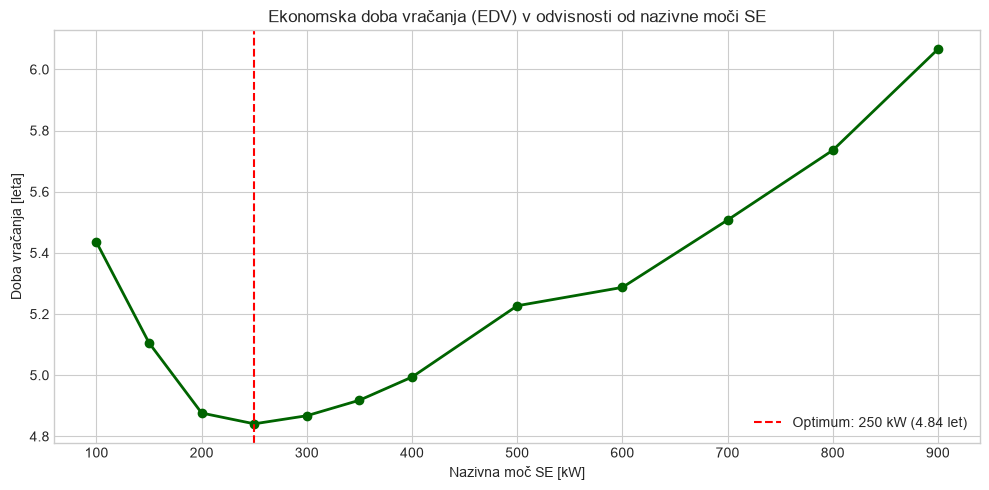

In [120]:
# Graf odvisnosti EDV od moči SE
plt.figure(figsize=(10, 5))
plt.plot(scenariji['Moc_SE_kW'], scenariji['EDV_let'], marker='o', color='darkgreen', linewidth=2)
plt.axvline(najboljsa_edv['Moc_SE_kW'], color='red', linestyle='--', label=f"Optimum: {najboljsa_edv['Moc_SE_kW']} kW ({najboljsa_edv['EDV_let']:.2f} let)")
plt.title('Ekonomska doba vračanja (EDV) v odvisnosti od nazivne moči SE')
plt.xlabel('Nazivna moč SE [kW]')
plt.ylabel('Doba vračanja [leta]')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Zaključek
Analiza nam je glede na naše vhodne podatke izbrala najbolj ekonomično velikost sončne elektrarne za naše potrebe. 